# 11 Probability Ensemble Experiment

Try weighted probability averaging between the A/B swap TF-IDF model and the word+char TF-IDF model. This notebook only reads saved predictions and does not train any model.

## 1. Imports and Path Setup

Set up paths, constants, and output folders.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, log_loss

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
LABELS = [0, 1, 2]
BEST_SINGLE_MODEL_LOG_LOSS = 1.078106
PROBABILITY_COLUMNS = ['prob_A_win', 'prob_B_win', 'prob_tie']
SUBMISSION_PROBABILITY_COLUMNS = ['winner_model_a', 'winner_model_b', 'winner_tie']
SUBMISSION_COLUMNS = ['id', 'winner_model_a', 'winner_model_b', 'winner_tie']

current_dir = Path.cwd().resolve()
if current_dir.name.lower() == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

oof_dir = project_root / 'outputs' / 'oof'
logs_dir = project_root / 'outputs' / 'logs'
figures_dir = project_root / 'outputs' / 'figures'
submissions_dir = project_root / 'outputs' / 'submissions'

for output_dir in [logs_dir, figures_dir, submissions_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

ab_swap_valid_path = oof_dir / 'tfidf_lr_ab_swap_valid_predictions.csv'
word_char_valid_path = oof_dir / 'tfidf_word_char_ab_swap_valid_predictions.csv'
ab_swap_submission_path = submissions_dir / 'tfidf_lr_ab_swap_avg_submission.csv'
word_char_submission_path = submissions_dir / 'tfidf_word_char_ab_swap_smooth_submission.csv'
ensemble_results_path = logs_dir / 'probability_ensemble_results.csv'
ensemble_figure_path = figures_dir / 'probability_ensemble_log_loss.png'
ensemble_submission_path = submissions_dir / 'ensemble_ab_swap_word_char_submission.csv'
experiment_results_path = logs_dir / 'experiment_results.csv'

print(f'Project root: {project_root}')
for path in [ab_swap_valid_path, word_char_valid_path, ab_swap_submission_path, word_char_submission_path]:
    print(f'{path.exists()} -> {path}')

Project root: D:\LLM_Classification_finetuning
True -> D:\LLM_Classification_finetuning\outputs\oof\tfidf_lr_ab_swap_valid_predictions.csv
True -> D:\LLM_Classification_finetuning\outputs\oof\tfidf_word_char_ab_swap_valid_predictions.csv
True -> D:\LLM_Classification_finetuning\outputs\submissions\tfidf_lr_ab_swap_avg_submission.csv
True -> D:\LLM_Classification_finetuning\outputs\submissions\tfidf_word_char_ab_swap_smooth_submission.csv


## 2. Read and Align Validation Predictions

Read the two OOF prediction files, align by id, and verify that labels match.

In [2]:
ab_swap_valid = pd.read_csv(ab_swap_valid_path, encoding='utf-8-sig')
word_char_valid = pd.read_csv(word_char_valid_path, encoding='utf-8-sig')

required_valid_columns = {'id', 'label', 'label_name', 'prob_A_win', 'prob_B_win', 'prob_tie'}
missing_ab_swap_columns = sorted(required_valid_columns - set(ab_swap_valid.columns))
missing_word_char_columns = sorted(required_valid_columns - set(word_char_valid.columns))

if missing_ab_swap_columns:
    raise ValueError(f'ab swap valid file missing columns: {missing_ab_swap_columns}')
if missing_word_char_columns:
    raise ValueError(f'word char valid file missing columns: {missing_word_char_columns}')

ab_swap_valid_small = ab_swap_valid[['id', 'label', 'label_name'] + PROBABILITY_COLUMNS].copy()
word_char_valid_small = word_char_valid[['id', 'label'] + PROBABILITY_COLUMNS].copy()

merged_valid = ab_swap_valid_small.merge(
    word_char_valid_small,
    on='id',
    suffixes=('_ab_swap', '_word_char'),
    how='inner',
)

if len(merged_valid) != len(ab_swap_valid) or len(merged_valid) != len(word_char_valid):
    raise ValueError('Validation prediction files are not perfectly aligned by id.')

if not (merged_valid['label_ab_swap'].to_numpy() == merged_valid['label_word_char'].to_numpy()).all():
    raise ValueError('Labels do not match after aligning validation predictions by id.')

y_valid = merged_valid['label_ab_swap'].astype(int).to_numpy()
ab_swap_probs = merged_valid[[f'{col}_ab_swap' for col in PROBABILITY_COLUMNS]].to_numpy()
word_char_probs = merged_valid[[f'{col}_word_char' for col in PROBABILITY_COLUMNS]].to_numpy()

print(f'ab_swap_valid shape: {ab_swap_valid.shape}')
print(f'word_char_valid shape: {word_char_valid.shape}')
print(f'merged_valid shape: {merged_valid.shape}')
display(merged_valid.head())

ab_swap_valid shape: (11496, 14)
word_char_valid shape: (11496, 15)
merged_valid shape: (11496, 10)


,id,label_ab_swap,label_name,prob_A_win_ab_swap,prob_B_win_ab_swap,prob_tie_ab_swap,label_word_char,prob_A_win_word_char,prob_B_win_word_char,prob_tie_word_char
0,2098233919,0,A_win,0.358578,0.360242,0.281180,0,0.368086,0.369637,0.262276
1,2789033728,1,B_win,0.357878,0.358176,0.283946,1,0.360781,0.361187,0.278032
2,4198930172,2,tie,0.355366,0.354856,0.289778,2,0.371834,0.371159,0.257008
3,2396441388,1,B_win,0.352141,0.352479,0.295380,1,0.330962,0.331494,0.337545
4,3592485435,2,tie,0.338684,0.338558,0.322758,2,0.341388,0.341374,0.317238


## 3. Weight Search on Validation Set

Search ensemble weights from 0.0 to 1.0 and evaluate log loss, accuracy, and macro F1.

In [3]:
weight_list = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ensemble_results = []

for weight_ab_swap in weight_list:
    weight_word_char = 1 - weight_ab_swap
    ensemble_probs = weight_ab_swap * ab_swap_probs + weight_word_char * word_char_probs
    ensemble_pred = np.argmax(ensemble_probs, axis=1)

    result = {
        'weight_ab_swap': weight_ab_swap,
        'weight_word_char': weight_word_char,
        'valid_log_loss': log_loss(y_valid, ensemble_probs, labels=LABELS),
        'valid_accuracy': accuracy_score(y_valid, ensemble_pred),
        'valid_macro_f1': f1_score(y_valid, ensemble_pred, average='macro'),
    }
    ensemble_results.append(result)
    print(
        f"weight_ab_swap={weight_ab_swap:.1f}, "
        f"log_loss={result['valid_log_loss']:.6f}, "
        f"accuracy={result['valid_accuracy']:.6f}, "
        f"macro_f1={result['valid_macro_f1']:.6f}"
    )

ensemble_results_df = pd.DataFrame(ensemble_results)
ensemble_results_df = ensemble_results_df.sort_values('valid_log_loss', ascending=True).reset_index(drop=True)

best_ensemble = ensemble_results_df.iloc[0]
best_weight_ab_swap = float(best_ensemble['weight_ab_swap'])
best_weight_word_char = float(best_ensemble['weight_word_char'])
best_valid_log_loss = float(best_ensemble['valid_log_loss'])
best_valid_accuracy = float(best_ensemble['valid_accuracy'])
best_valid_macro_f1 = float(best_ensemble['valid_macro_f1'])

print('\nBest ensemble result:')
display(best_ensemble.to_frame().T)

ensemble_results_df.to_csv(ensemble_results_path, index=False, encoding='utf-8-sig')
print(f'Saved ensemble results: {ensemble_results_path}')

weight_ab_swap=0.0, log_loss=1.078998, accuracy=0.387352, macro_f1=0.387994
weight_ab_swap=0.1, log_loss=1.078745, accuracy=0.389092, macro_f1=0.389772
weight_ab_swap=0.2, log_loss=1.078528, accuracy=0.389527, macro_f1=0.390254
weight_ab_swap=0.3, log_loss=1.078349, accuracy=0.390484, macro_f1=0.391263
weight_ab_swap=0.4, log_loss=1.078206, accuracy=0.391788, macro_f1=0.392592
weight_ab_swap=0.5, log_loss=1.078099, accuracy=0.393354, macro_f1=0.394132
weight_ab_swap=0.6, log_loss=1.078028, accuracy=0.395877, macro_f1=0.396747
weight_ab_swap=0.7, log_loss=1.077993, accuracy=0.396312, macro_f1=0.397224
weight_ab_swap=0.8, log_loss=1.077994, accuracy=0.396573, macro_f1=0.397457
weight_ab_swap=0.9, log_loss=1.078032, accuracy=0.395442, macro_f1=0.396303
weight_ab_swap=1.0, log_loss=1.078106, accuracy=0.395442, macro_f1=0.396300

Best ensemble result:


d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:2

,weight_ab_swap,weight_word_char,valid_log_loss,valid_accuracy,valid_macro_f1
0,0.7,0.3,1.077993,0.396312,0.397224


Saved ensemble results: D:\LLM_Classification_finetuning\outputs\logs\probability_ensemble_results.csv


## 4. Plot Ensemble Log Loss

Plot validation log loss as a function of the A/B swap model weight.

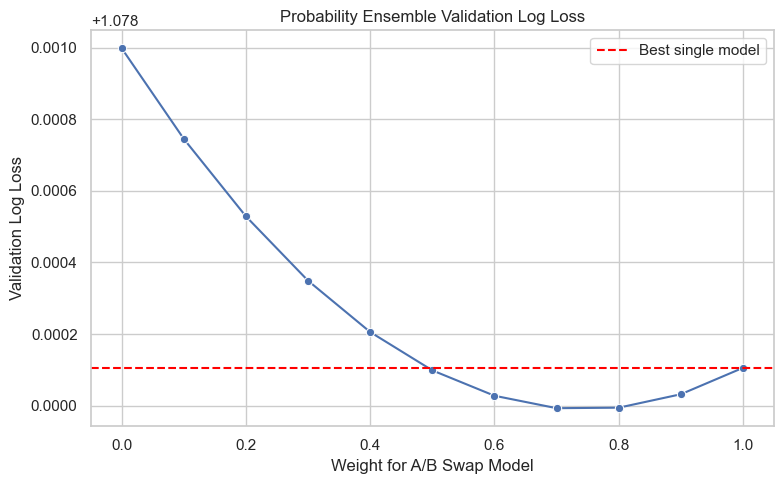

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\probability_ensemble_log_loss.png


In [4]:
plot_df = pd.DataFrame(ensemble_results).sort_values('weight_ab_swap')

plt.figure(figsize=(8, 5))
sns.lineplot(data=plot_df, x='weight_ab_swap', y='valid_log_loss', marker='o')
plt.axhline(BEST_SINGLE_MODEL_LOG_LOSS, color='red', linestyle='--', label='Best single model')
plt.title('Probability Ensemble Validation Log Loss')
plt.xlabel('Weight for A/B Swap Model')
plt.ylabel('Validation Log Loss')
plt.legend()
plt.tight_layout()
plt.savefig(ensemble_figure_path, dpi=150)
plt.show()

print(f'Saved figure: {ensemble_figure_path}')

## 5. Optional Test Submission Ensemble

If the best validation ensemble improves over the current best single-model log loss, blend the two test submissions.

In [5]:
submission_created = False
ensemble_submission = None

if best_valid_log_loss < BEST_SINGLE_MODEL_LOG_LOSS:
    ab_swap_submission = pd.read_csv(ab_swap_submission_path, encoding='utf-8-sig')
    word_char_submission = pd.read_csv(word_char_submission_path, encoding='utf-8-sig')

    missing_ab_submission_columns = sorted(set(SUBMISSION_COLUMNS) - set(ab_swap_submission.columns))
    missing_word_char_submission_columns = sorted(set(SUBMISSION_COLUMNS) - set(word_char_submission.columns))

    if missing_ab_submission_columns:
        raise ValueError(f'ab swap submission missing columns: {missing_ab_submission_columns}')
    if missing_word_char_submission_columns:
        raise ValueError(f'word char submission missing columns: {missing_word_char_submission_columns}')

    merged_submission = ab_swap_submission[SUBMISSION_COLUMNS].merge(
        word_char_submission[SUBMISSION_COLUMNS],
        on='id',
        suffixes=('_ab_swap', '_word_char'),
        how='inner',
    )

    if len(merged_submission) != len(ab_swap_submission) or len(merged_submission) != len(word_char_submission):
        raise ValueError('Submission files are not perfectly aligned by id.')

    ab_submission_probs = merged_submission[[f'{col}_ab_swap' for col in SUBMISSION_PROBABILITY_COLUMNS]].to_numpy()
    word_char_submission_probs = merged_submission[[f'{col}_word_char' for col in SUBMISSION_PROBABILITY_COLUMNS]].to_numpy()
    ensemble_submission_probs = best_weight_ab_swap * ab_submission_probs + best_weight_word_char * word_char_submission_probs

    ensemble_submission = pd.DataFrame({
        'id': merged_submission['id'],
        'winner_model_a': ensemble_submission_probs[:, 0],
        'winner_model_b': ensemble_submission_probs[:, 1],
        'winner_tie': ensemble_submission_probs[:, 2],
    })

    ensemble_submission.to_csv(ensemble_submission_path, index=False, encoding='utf-8-sig')
    submission_created = True
    print(f'Saved ensemble submission: {ensemble_submission_path}')
else:
    print('Best ensemble did not improve over 1.078106. Test submission ensemble was not created.')

Saved ensemble submission: D:\LLM_Classification_finetuning\outputs\submissions\ensemble_ab_swap_word_char_submission.csv


## 6. Submission Checks

If an ensemble submission was created, validate its shape, columns, probability sums, and missing values.

In [6]:
if submission_created:
    probability_sum = ensemble_submission[SUBMISSION_PROBABILITY_COLUMNS].sum(axis=1)
    print(f'submission shape: {ensemble_submission.shape}')
    print(f'submission columns: {ensemble_submission.columns.tolist()}')
    print(f'submission columns correct: {ensemble_submission.columns.tolist() == SUBMISSION_COLUMNS}')
    print(f'probability sums close to 1: {np.allclose(probability_sum, 1.0, atol=1e-6)}')
    print(f'submission has NaN: {ensemble_submission.isna().any().any()}')
    display(ensemble_submission.head())
else:
    print('No ensemble submission to check.')

submission shape: (3, 4)
submission columns: ['id', 'winner_model_a', 'winner_model_b', 'winner_tie']
submission columns correct: True
probability sums close to 1: True
submission has NaN: False


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.244618,0.244618,0.510763
1,211333,0.350318,0.349608,0.300074
2,1233961,0.396866,0.396866,0.206268


## 7. Save Experiment Result

Append the best ensemble validation result to `experiment_results.csv`.

In [7]:
experiment_result = pd.DataFrame([
    {
        'model_name': 'ensemble_ab_swap_word_char',
        'valid_log_loss': best_valid_log_loss,
        'valid_accuracy': best_valid_accuracy,
        'valid_macro_f1': best_valid_macro_f1,
        'max_features': '',
        'ngram_range': '',
        'C': np.nan,
        'random_state': RANDOM_STATE,
        'notes': 'Weighted probability ensemble of A/B swap TF-IDF model and word+char TF-IDF model.',
        'weight_ab_swap': best_weight_ab_swap,
        'weight_word_char': best_weight_word_char,
        'submission_created': submission_created,
    }
])

if experiment_results_path.exists():
    previous_results = pd.read_csv(experiment_results_path, encoding='utf-8-sig')
    experiment_results = pd.concat([previous_results, experiment_result], ignore_index=True)
else:
    experiment_results = experiment_result

experiment_results.to_csv(experiment_results_path, index=False, encoding='utf-8-sig')

print(f'Saved experiment results: {experiment_results_path}')
display(experiment_results.tail())

Saved experiment results: D:\LLM_Classification_finetuning\outputs\logs\experiment_results.csv


,model_name,valid_log_loss,valid_accuracy,valid_macro_f1,max_features,ngram_range,C,random_state,notes,model_checkpoint,max_length,train_rows,valid_rows,train_batch_size,eval_batch_size,gradient_accumulation_steps,train_rows_original,train_rows_augmented,best_alpha,raw_valid_log_loss,weight_ab_swap,weight_word_char,submission_created
4,distilbert_debug,1.078755,0.392222,0.379731,NaN,NaN,NaN,42,DistilBERT debug finetuning on at most 1500 samples per class.,distilbert-base-uncased,256.0,3600.0,900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,distilbert_medium,1.086948,0.371944,0.371848,NaN,NaN,NaN,42,"DistilBERT finetuning on at most 6000 samples per class, max_length=384.",distilbert-base-uncased,384.0,14400.0,3600.0,8.0,16.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,tfidf_logistic_regression_ab_swap,1.078106,0.395442,0.396300,100000.0,"(1, 2)",0.1,42,TF-IDF Logistic Regression with A/B swap augmentation. Validation set not augmented. Swap-test averaging submission also saved.,NaN,NaN,NaN,11496.0,NaN,NaN,NaN,45981.0,91962.0,NaN,NaN,NaN,NaN,NaN
7,tfidf_word_char_ab_swap_smooth,1.078998,0.387352,0.387994,word_100000_char_50000,"word_(1,2)_char_(3,5)",0.1,42,"TF-IDF word + char features with A/B swap augmentation, swap-test averaging, and probability smoothing.",NaN,NaN,NaN,11496.0,NaN,NaN,NaN,45981.0,91962.0,0.1,1.079283,NaN,NaN,NaN
8,ensemble_ab_swap_word_char,1.077993,0.396312,0.397224,,,NaN,42,Weighted probability ensemble of A/B swap TF-IDF model and word+char TF-IDF model.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7,0.3,True


## 8. Final Checks

Print saved files and finish.

In [8]:
print(f'best_weight_ab_swap: {best_weight_ab_swap}')
print(f'best_weight_word_char: {best_weight_word_char}')
print(f'best_valid_log_loss: {best_valid_log_loss:.6f}')
print(f'best_valid_accuracy: {best_valid_accuracy:.6f}')
print(f'best_valid_macro_f1: {best_valid_macro_f1:.6f}')

print('\nSaved files:')
for path in [ensemble_results_path, ensemble_figure_path, experiment_results_path]:
    print(f'{path.exists()} -> {path}')

if submission_created:
    print(f'{ensemble_submission_path.exists()} -> {ensemble_submission_path}')

print('Probability ensemble experiment finished successfully.')

best_weight_ab_swap: 0.7
best_weight_word_char: 0.30000000000000004
best_valid_log_loss: 1.077993
best_valid_accuracy: 0.396312
best_valid_macro_f1: 0.397224

Saved files:
True -> D:\LLM_Classification_finetuning\outputs\logs\probability_ensemble_results.csv
True -> D:\LLM_Classification_finetuning\outputs\figures\probability_ensemble_log_loss.png
True -> D:\LLM_Classification_finetuning\outputs\logs\experiment_results.csv
True -> D:\LLM_Classification_finetuning\outputs\submissions\ensemble_ab_swap_word_char_submission.csv
Probability ensemble experiment finished successfully.
